# **Saturation momentum dependence of classical momentum broadening from qhat.py**

This notebook computes the momentum broadening of a light-like parton traversing the Glasma for various values of the saturation scale $Q_s$. The `qhat.py` module computes the Lorentz force along light-like Wilson lines and accumulates the momentum broadening using gauge-covariant parallel transport.

## Default simulation parameters for the Glasma

In [1]:
import numpy as np

# hbar * c [GeV * fm]
hbarc = 0.197326 

# Simulation box 
L = 1.0      
N = 512    
TAU_SIM = 0.2   
DTS = 16     

# Glasma
su_group = 'su3'
ns = 50    
factor = 0.8        
uv = 10.0        
g = 2.0   

# Mode: 'fixedqs' or 'fixedg2mu'
# mode = 'fixedqs'
mode = 'fixedg2mu'

# fixedqs: vary Qs, derive g2mu = Qs / factor, ir = 0.1 * g2mu
Qss = [1, 1.5, 2, 2.5]

# fixedg2mu: vary g2mu directly, fixed ir
g2mus = [1, 1.5, 2, 2.5]
ir_fixed = 0.3

nevents = 1

## Set environment variables

In [2]:
import os

os.environ["MY_NUMBA_TARGET"] = "cuda"

# os.environ["MY_NUMBA_TARGET"] = "numba"
# import warnings
# from numba.core.errors import NumbaPerformanceWarning
# warnings.filterwarnings('ignore', category=NumbaPerformanceWarning)


os.environ["PRECISION"] = "double"
os.environ["GAUGE_GROUP"] = su_group

# Import relevant modules
import sys
sys.path.append('..')

# Glasma modules
import curraun.core as core
import curraun.mv as mv
import curraun.initial as initial
initial.DEBUG = False

import curraun.su as su
from curraun.numba_target import use_cuda
if use_cuda:
    from numba import cuda

# Qhat module
import curraun.qhat as qhat

import pickle
from tqdm import tqdm

os.makedirs('results', exist_ok=True)
os.makedirs('plots', exist_ok=True)

Using CUDA
Using SU(3)
Using double precision


## Simulation routine for evolving the Glasma & computing momentum broadening
Computes the momentum broadening using light-like Wilson lines from the `qhat.py` module.

In [3]:
def simulate_qhat(p, ev): 
    g2mu = p['g2mu']
    ir = p['ir']
    tau_sim = p['tau_sim']
    mu = g2mu / g**2

    # Derived parameters
    a = L / N
    E0 = N / L * hbarc
    DT = 1.0 / DTS
    maxt = int(tau_sim / a * DTS)

    # Initialize Glasma fields
    s = core.Simulation(N, DT, g)
    va = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    vb = mv.wilson(s, mu=mu / E0, m=ir / E0, uv=uv / E0, num_sheets=ns)
    initial.init(s, va, vb)

    # Initialize the qhat module
    qhat_tforce = qhat.TransportedForce(s, E0)
    mom_broad, tau_arr = [], []

    if use_cuda:
        qhat_tforce.copy_to_device()

    with tqdm(total=maxt) as pbar:
        for t in range(maxt):
            # Collect momentum broadening at every full time step
            if t % DTS == 0:
                if use_cuda:
                    qhat_tforce.copy_mean_to_host()

                # Units: GeV^2
                mom_broad.append(qhat_tforce.p_perp_mean * E0 ** 2)
                # Units: fm
                tau_arr.append(t * a / DTS)

                if use_cuda:
                    qhat_tforce.copy_mean_to_device()

            qhat_tforce.compute()

            # Evolve Glasma fields
            core.evolve_leapfrog(s)

            pbar.set_description("Event " + str(ev + 1))
            pbar.update(1)

    return np.array(mom_broad), np.array(tau_arr)

## Running the qhat module over multiple Glasma events
This is done for various values of $Q_s$ (fixedqs) or $g^2\mu$ (fixedg2mu). Afterwards event averages are performed and the results are stored to a pickle file.

In [4]:
import warnings
warnings.filterwarnings('ignore')

if mode == 'fixedqs':
    scan_values = Qss
    tag_prefix = 'Qs_'
elif mode == 'fixedg2mu':
    scan_values = g2mus
    tag_prefix = 'g2mu_'

p = {}
mom_broad, tau = {}, {}
for val in scan_values:
    tag = tag_prefix + str(val)

    if mode == 'fixedqs':
        print('Saturation momentum', val, 'GeV')
        p['g2mu'] = val / factor
        p['ir'] = 0.1 * p['g2mu']
        # p['tau_sim'] = np.max(scan_values) * TAU_SIM / val
        p['tau_sim'] = TAU_SIM 
    elif mode == 'fixedg2mu':
        print('g2mu', val, 'GeV')
        p['g2mu'] = val
        p['ir'] = ir_fixed
        # p['tau_sim'] = np.max(scan_values) * TAU_SIM / val
        p['tau_sim'] = TAU_SIM 

    mom_broads = []
    for ev in range(nevents):
        mom_broad_ev, tau_ev = simulate_qhat(p, ev)
        mom_broads.append(mom_broad_ev)

    mom_broad[tag] = np.mean(mom_broads, axis=0)
    tau[tag] = tau_ev

# Save results
output = {
    'mode': mode,
    'scan_values': scan_values,
    'tag_prefix': tag_prefix,
    'mom_broad': mom_broad,
    'tau': tau,
}
filename = f'results/{mode}_mom_broad_qhat.pickle'
with open(filename, 'wb') as handle:
    pickle.dump(output, handle)

g2mu 1 GeV


Event 1: 100%|██████████| 1638/1638 [04:38<00:00,  5.87it/s]


g2mu 1.5 GeV


Event 1: 100%|██████████| 1638/1638 [04:28<00:00,  6.10it/s]


g2mu 2 GeV


Event 1: 100%|██████████| 1638/1638 [04:26<00:00,  6.15it/s]


g2mu 2.5 GeV


Event 1: 100%|██████████| 1638/1638 [04:31<00:00,  6.03it/s]


## Read data from files

In [5]:
import pickle
import numpy as np

hbarc = 0.197326

filename = f'results/{mode}_mom_broad_qhat.pickle'
with open(filename, 'rb') as handle:
    output = pickle.load(handle)

mom_broad = output['mom_broad']
tau = output['tau']
scan_values = output['scan_values']
tag_prefix = output['tag_prefix']

## Plot the results in physical units
Two panels showing the longitudinal $\langle\delta p_L^2\rangle$ and transverse $\langle\delta p_T^2\rangle$ momentum broadening together, and the transport coefficients $\hat{q}_L$ and $\hat{q}_T$.

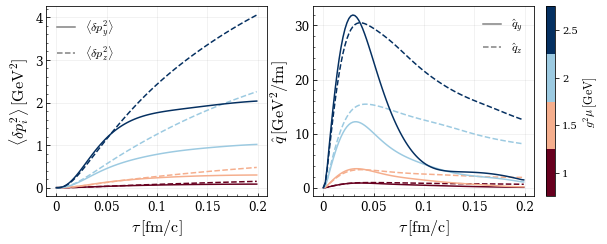

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.cm import ScalarMappable

# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "text.latex.preamble": r"\usepackage{txfonts}"
# })

plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
plt.rcParams['mathtext.fontset'] = 'cm'

# Colorbar label depending on mode
if mode == 'fixedqs':
    cbar_label = r'$Q_s\,\mathrm{[GeV]}$'
elif mode == 'fixedg2mu':
    cbar_label = r'$g^2\mu\,\mathrm{[GeV]}$'

# Colors from RdBu colormap
n_scan = len(scan_values)
cmap_rb = plt.cm.get_cmap('RdBu', 20)
colors = [cmap_rb(i) for i in np.linspace(0, 1, n_scan)]

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

for i, val in enumerate(scan_values):
    tag = tag_prefix + str(val)
    t = tau[tag]
    mb = mom_broad[tag]

    # Longitudinal (z/beam direction)
    pL2 = mb[:, 2]
    # Transverse to beam (y)
    pT2 = mb[:, 1]
    # qhat = d<dp^2>/dtau [GeV^2/fm]
    qhat_L = np.gradient(pL2, t)
    qhat_T = np.gradient(pT2, t)

    axes[0].plot(t, pL2, linewidth=1.5, linestyle='--', color=colors[i])
    axes[0].plot(t, pT2, linewidth=1.5, color=colors[i])
    axes[1].plot(t, qhat_L, linewidth=1.5, linestyle='--', color=colors[i])
    axes[1].plot(t, qhat_T, linewidth=1.5, color=colors[i])

# Axes labels
axes[0].set_xlabel(r'$\tau\,\mathrm{[fm/c]}$', fontsize=16)
axes[0].set_ylabel(r'$\langle\delta p^2_i\rangle\,\mathrm{[GeV^2]}$', fontsize=16)
axes[1].set_xlabel(r'$\tau\,\mathrm{[fm/c]}$', fontsize=16)
axes[1].set_ylabel(r'$\hat{q}\,\mathrm{[GeV^2/fm]}$', fontsize=16)

# Styling
for ax in axes:
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
    ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')

# Legends
legend_left = [
    Line2D([0], [0], color='gray', lw=1.5, linestyle='-', label=r'$\langle\delta p_y^2\rangle$'),
    Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label=r'$\langle\delta p_z^2\rangle$'),
]
axes[0].legend(handles=legend_left, fontsize=12, frameon=False, loc='upper left', handlelength=1.5)

legend_right = [
    Line2D([0], [0], color='gray', lw=1.5, linestyle='-', label=r'$\hat{q}_y$'),
    Line2D([0], [0], color='gray', lw=1.5, linestyle='--', label=r'$\hat{q}_z$'),
]
axes[1].legend(handles=legend_right, fontsize=12, frameon=False, loc='upper right', handlelength=1.5)

# Colorbar on the right side of the figure
bounds = np.arange(0.5, n_scan + 1.5)
norm_cb = BoundaryNorm(bounds, n_scan)
cmap_disc = ListedColormap(colors)
sm = ScalarMappable(cmap=cmap_disc, norm=norm_cb)
sm.set_array([])

plt.tight_layout()

cbar = fig.colorbar(sm, ax=axes.tolist(), shrink=1.0, pad=0.02)
cbar.set_ticks(range(1, n_scan + 1))
cbar.set_ticklabels([str(v) for v in scan_values])
cbar.ax.tick_params(labelsize=10)
cbar.set_label(cbar_label, fontsize=12)

# plt.savefig(f'plots/{mode}_mom_broad_qhat.png', dpi=300, bbox_inches='tight')
plt.show()

## Plot the results in scaled units
Rescaling by the scan variable ($Q_s$ or $g^2\mu$) on both axes. Both $\langle\delta p_L^2\rangle$ and $\langle\delta p_T^2\rangle$ are shown on the first panel, and the scaled $\hat{q}_{L,T}$ on the second.

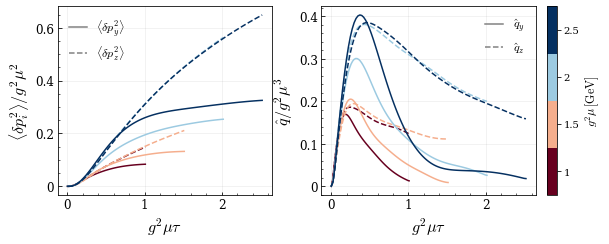

In [8]:
# Labels depending on mode
if mode == 'fixedqs':
    scale_sym = r'Q_s'
elif mode == 'fixedg2mu':
    scale_sym = r'g^2\mu'

fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

for i, val in enumerate(scan_values):
    tag = tag_prefix + str(val)
    t_scaled = tau[tag] * val / hbarc
    mb = mom_broad[tag]

    # Longitudinal (z/beam direction) scaled
    pL2 = mb[:, 2] / val**2
    # Transverse to beam (y) scaled
    pT2 = mb[:, 1] / val**2
    # Scaled qhat
    qhat_L = np.gradient(pL2, t_scaled)
    qhat_T = np.gradient(pT2, t_scaled)

    axes[0].plot(t_scaled, pL2, linewidth=1.5, linestyle='--', color=colors[i])
    axes[0].plot(t_scaled, pT2, linewidth=1.5, color=colors[i])
    axes[1].plot(t_scaled, qhat_L, linewidth=1.5, linestyle='--', color=colors[i])
    axes[1].plot(t_scaled, qhat_T, linewidth=1.5, color=colors[i])

# Axes labels
axes[0].set_xlabel(rf'${scale_sym}\tau$', fontsize=16)
axes[0].set_ylabel(rf'$\langle\delta p^2_i\rangle/{scale_sym}^2$', fontsize=16)
axes[1].set_xlabel(rf'${scale_sym}\tau$', fontsize=16)
axes[1].set_ylabel(rf'$\hat{{q}}/{scale_sym}^3$', fontsize=16)

# axes[1].set_xlim(0,2)

# Styling
for ax in axes:
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: '{:g}'.format(x)))
    ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.1)
    ax.tick_params(axis='both', which='major', direction='in', labelsize=12)
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', direction='in')

# Legends
legend_left = [
    Line2D([0], [0], color='gray', lw=1.5, linestyle='-',
           label=rf'$\langle\delta p_y^2\rangle$'),
    Line2D([0], [0], color='gray', lw=1.5, linestyle='--',
           label=rf'$\langle\delta p_z^2\rangle$'),
]
axes[0].legend(handles=legend_left, fontsize=12, frameon=False, loc='upper left', handlelength=1.5)

legend_right = [
    Line2D([0], [0], color='gray', lw=1.5, linestyle='-',
           label=rf'$\hat{{q}}_y$'),
    Line2D([0], [0], color='gray', lw=1.5, linestyle='--',
           label=rf'$\hat{{q}}_z$'),
]
axes[1].legend(handles=legend_right, fontsize=12, frameon=False, loc='upper right', handlelength=1.5)

# Colorbar on the right side of the figure
sm = ScalarMappable(cmap=cmap_disc, norm=norm_cb)
sm.set_array([])

plt.tight_layout()

cbar = fig.colorbar(sm, ax=axes.tolist(), shrink=1.0, pad=0.02)
cbar.set_ticks(range(1, n_scan + 1))
cbar.set_ticklabels([str(v) for v in scan_values])
cbar.ax.tick_params(labelsize=10)
cbar.set_label(cbar_label, fontsize=12)

# plt.savefig(f'plots/{mode}_mom_broad_scaled_qhat.png', dpi=300, bbox_inches='tight')
plt.show()